# Notebook 3 — Full Research Implementation
**FIRE 691 | Regime-Conditioned Brinson Attribution with HMM Regime Detection**

Executes the complete research pipeline. Reads from Notebook 1 outputs.
All results are consolidated in the final cell.

**Pipeline:**
1. STREV residualization → momentum signal
2. GP/Assets selection universe (annual July rebalance)
3. Walk-forward daily HMM → monthly regime posteriors
4. Probability-weighted portfolio construction
5. Monthly Brinson attribution with Carino linking
6. Ferson-Schadt regime tests (H₁ and H₂)

**Requires:** All 14 parquet files in `outputs/` from Notebook 1.


## Cell 1 — Configuration

In [ ]:
import os

# ── CONFIGURATION — must match Notebooks 1 and 2 ────────────────
ROOT = (
   "YOUR_GOOGLE_DRIVE_PATH/"
)
# ────────────────────────────────────────────────────────────────

OUTPUTS = ROOT + "outputs/"

FULL_START  = "1990-01-01"
FULL_END    = "2024-12-31"
IS_START    = "1990-01-01"
IS_END      = "2003-12-31"
OOS_START   = "2004-01-01"
ATTR_START  = "1995-01-01"  # first usable month after 60-month STREV init window

# ── Attribution design parameters ───────────────────────────────
STREV_WINDOW    = 60    # rolling OLS window for STREV residualization
MOM_SKIP        = 2     # skip most recent month (t-1)
MOM_WINDOW      = 12    # momentum lookback in months
LAMBDA          = 0.30  # active tilt budget for bull posture
MINVAR_CAP      = 0.15  # max weight per industry in bear posture
GP_TERCILE      = 0.67  # top-tercile threshold for GP/Assets screen
COV_WINDOW      = 60    # rolling covariance window for min-var

# ── HMM parameters (confirmed from Notebook 2) ──────────────────
OPTIMAL_K       = 3     # k=3 confirmed (Ang & Bekaert 2002)
HMM_RESTARTS    = 20
HMM_ITERS       = 1000

print(f"ROOT       : {ROOT}")
print(f"OUTPUTS    : {OUTPUTS}")
print(f"Attr period: {ATTR_START} to {FULL_END}")
print(f"IS period  : {IS_START} to {IS_END}")
print(f"OOS period : {OOS_START} to {FULL_END}")


## Cell 2 — Imports, Drive Mount, Package Install

In [2]:
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
try:
    drive.mount("/content/drive")
except ValueError:
    print("Drive already mounted.")

import subprocess
subprocess.run(["pip", "install", "hmmlearn", "scipy", "-q"], check=False)

import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn           as sns
from scipy.optimize      import minimize
!pip install statsmodels
from statsmodels.regression.linear_model import OLS
from statsmodels.tools   import add_constant
from hmmlearn.hmm        import GaussianHMM

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.6f}".format)
print("Libraries loaded.")


Mounted at /content/drive
Libraries loaded.


## Cell 3 — Load Parquet Files from Notebook 1

In [3]:
ff12_ret        = pd.read_parquet(OUTPUTS + "ff12_returns.parquet")
strev_raw       = pd.read_parquet(OUTPUTS + "strev_factor.parquet")
ff5_raw         = pd.read_parquet(OUTPUTS + "ff5_factors.parquet")
crsp_msf        = pd.read_parquet(OUTPUTS + "crsp_msf.parquet")
crsp_di_s       = pd.read_parquet(OUTPUTS + "crsp_daily_index.parquet")
realvol_daily   = pd.read_parquet(OUTPUTS + "realvol_daily.parquet")
vix_daily       = pd.read_parquet(OUTPUTS + "vix_daily.parquet")
nber_raw        = pd.read_parquet(OUTPUTS + "nber.parquet")

for df in [ff12_ret, strev_raw, ff5_raw, nber_raw]:
    df["date"] = pd.to_datetime(df["date"])
for df in [crsp_di_s, realvol_daily, vix_daily]:
    df["date"] = pd.to_datetime(df["date"])
crsp_msf["date"] = pd.to_datetime(crsp_msf["date"])

# Named FF12 industries — Other is passive throughout
ALL_INDUSTRIES  = [c for c in ff12_ret.columns if c != "date"]
NAMED_INDUSTRIES = [i for i in ALL_INDUSTRIES if i != "Other"]

print(f"FF12 returns    : {len(ff12_ret):,} months")
print(f"Named industries: {NAMED_INDUSTRIES}")
print(f"Passive industry: ['Other'] — held at benchmark weight, excluded from signals")
print(f"CRSP monthly    : {len(crsp_msf):,} stock-months")
print(f"Daily index     : {len(crsp_di_s):,} trading days")


FF12 returns    : 420 months
Named industries: ['NoDur', 'Durbl', 'Manuf', 'Enrgy', 'Chems', 'BusEq', 'Telcm', 'Utils', 'Shops', 'Hlth', 'Money']
Passive industry: ['Other'] — held at benchmark weight, excluded from signals
CRSP monthly    : 2,444,656 stock-months
Daily index     : 8,817 trading days


## Cell 4 — STREV Residualization of FF12 Monthly Returns
60-month rolling OLS: industry_return ~ alpha + beta × ST_Rev.
Residuals are the STREV-purified returns used for momentum signal construction.
Applied to the 11 named industries only. Other is excluded.
Follows Gao, Li, Yuan and Zhou (2026): strips RSR drag before momentum ranking.


In [4]:
resid_data = (
    ff12_ret.merge(strev_raw[["date","ST_Rev"]], on="date", how="inner")
    .sort_values("date")
    .reset_index(drop=True)
)

def rolling_ols_resid(y_vals, x_vals, window):
    """Rolling OLS residuals: y ~ alpha + beta*x."""
    n = len(y_vals)
    resids = np.full(n, np.nan)
    for t in range(window - 1, n):
        y_w = y_vals[t - window + 1:t + 1]
        x_w = x_vals[t - window + 1:t + 1]
        X_w = np.column_stack([np.ones(window), x_w])
        try:
            beta = np.linalg.lstsq(X_w, y_w, rcond=None)[0]
            resids[t] = y_w[-1] - X_w[-1] @ beta
        except Exception:
            pass
    return resids

strev_vals = resid_data["ST_Rev"].values
resid_ff12 = resid_data[["date"]].copy()
for ind in NAMED_INDUSTRIES:
    resid_ff12[ind] = rolling_ols_resid(resid_data[ind].values, strev_vals, STREV_WINDOW)

resid_ff12 = resid_ff12.dropna(subset=NAMED_INDUSTRIES).reset_index(drop=True)

print(f"Residualized returns: {len(resid_ff12):,} months")
print(f"  Date range: {resid_ff12['date'].min().date()} to {resid_ff12['date'].max().date()}")
print(f"  First usable month after {STREV_WINDOW}-month init: {resid_ff12['date'].min().date()}")


Residualized returns: 361 months
  Date range: 1994-12-31 to 2024-12-31
  First usable month after 60-month init: 1994-12-31


## Cell 5 — Momentum Signal Construction
12-1 skip-month cumulative log return computed on STREV-residualized FF12 returns.
At time t: cumulative return from t-13 to t-2 (12 months, skipping t-1).
Cross-sectional rank score normalised to [-0.5, +0.5] for use in the bull-posture tilt.


In [5]:
def compute_momentum_signal(ret_df, industries, skip=MOM_SKIP, window=MOM_WINDOW):
    """12-1 skip-month momentum. Returns cumulative return and normalised rank score."""
    log_ret = np.log1p(ret_df[industries].clip(lower=-0.99))
    cum_ret = np.exp(log_ret.shift(skip).rolling(window).sum()) - 1
    result  = ret_df[["date"]].copy()
    for ind in industries:
        result[ind] = cum_ret[ind].values
    result = result.dropna(subset=industries).copy()

    # Cross-sectional rank score: rank-1 / (N-1) - 0.5 -> range [-0.5, +0.5]
    ranked = result[industries].rank(axis=1, method="average")
    n = len(industries)
    score_cols = {ind: f"{ind}_score" for ind in industries}
    for ind in industries:
        result[score_cols[ind]] = (ranked[ind] - 1) / (n - 1) - 0.5
    return result

mom_signal = compute_momentum_signal(resid_ff12, NAMED_INDUSTRIES)

print(f"Momentum signal: {len(mom_signal):,} months")
print(f"  Date range: {mom_signal['date'].min().date()} to {mom_signal['date'].max().date()}")
print(f"  Score range check (should be -0.5 to +0.5):")
score_cols = [f"{ind}_score" for ind in NAMED_INDUSTRIES]
print(f"    Min={mom_signal[score_cols].values.min():.4f}  Max={mom_signal[score_cols].values.max():.4f}")


Momentum signal: 348 months
  Date range: 1996-01-31 to 2024-12-31
  Score range check (should be -0.5 to +0.5):
    Min=-0.5000  Max=0.5000


## Cell 6 — GP/Assets Selection Universe (Annual July Rebalance)
Top tercile of each named FF12 industry by GP/Assets as of each July (fiscal year t-1 data).
Equal-weighted within each industry's top tercile.
Computes the monthly portfolio return for each industry's selected stocks.
Other industry: portfolio return = benchmark return (passive, zero selection effect).


In [6]:
# ── Build annual July GP/Assets tercile assignments ─────────────
july_msf = crsp_msf[
    (crsp_msf["date"].dt.month == 7) &
    crsp_msf["gp_at"].notna() &
    (crsp_msf["ff12"] != "Other")
].copy()
july_msf["year"] = july_msf["date"].dt.year

# Top-tercile threshold per industry per year
gp_threshold = (
    july_msf.groupby(["year","ff12"])["gp_at"]
    .quantile(GP_TERCILE)
    .reset_index()
    .rename(columns={"gp_at":"gp_threshold"})
)

# Assign tercile flag and rebalance year to all CRSP stock-months
crsp_msf["year"]  = crsp_msf["date"].dt.year
crsp_msf["month"] = crsp_msf["date"].dt.month
crsp_msf["rebal_year"] = np.where(
    crsp_msf["month"] >= 7,
    crsp_msf["year"],
    crsp_msf["year"] - 1
)

crsp_msf = crsp_msf.merge(
    gp_threshold.rename(columns={"year":"rebal_year"}),
    on=["rebal_year","ff12"], how="left"
)
crsp_msf["top_tercile"] = (
    crsp_msf["gp_at"].notna() &
    crsp_msf["gp_threshold"].notna() &
    (crsp_msf["gp_at"] >= crsp_msf["gp_threshold"])
)

# ── Compute monthly VALUE-WEIGHTED portfolio return per industry ─
# Value-weight by lagged market cap (prior month-end mktcap)
# This aligns with the value-weighted FF12 benchmark from French
# and eliminates the apples-to-oranges size mismatch

# Sort and compute lagged mktcap
crsp_msf = crsp_msf.sort_values(["permno","date"])
crsp_msf["lag_mktcap"] = crsp_msf.groupby("permno")["mktcap"].shift(1)

# Top-tercile universe: named FF12 industries only
top_tercile_msf = crsp_msf[
    crsp_msf["top_tercile"] &
    (crsp_msf["ff12"] != "Other") &
    crsp_msf["lag_mktcap"].notna() &
    (crsp_msf["lag_mktcap"] > 0) &
    crsp_msf["ret"].notna()
].copy()

# Value-weighted return = sum(w_i * r_i) where w_i = mktcap_i / sum(mktcap)
def vw_return(group):
    total_cap = group["lag_mktcap"].sum()
    if total_cap <= 0:
        return np.nan
    weights = group["lag_mktcap"] / total_cap
    return (weights * group["ret"]).sum()

sel_returns = (
    top_tercile_msf
    .groupby(["month_end","ff12"])
    .apply(vw_return)
    .unstack("ff12")
    .reset_index()
    .rename(columns={"month_end":"date"})
)
sel_returns["date"] = pd.to_datetime(sel_returns["date"])

# Ensure all named industries are present as columns
for ind in NAMED_INDUSTRIES:
    if ind not in sel_returns.columns:
        sel_returns[ind] = np.nan

# ── Benchmark returns (value-weighted FF12 from French) ──────────
bench_ret = ff12_ret.set_index("date")

print(f"Selection returns built: {len(sel_returns):,} months")
print(f"  Weighting: value-weighted by lagged market cap")
print(f"  Industries covered: {[c for c in sel_returns.columns if c != 'date']}")

# Coverage check
coverage = sel_returns[NAMED_INDUSTRIES].notna().mean()
print(f"\nAverage monthly coverage per industry:")
print(coverage.round(3).to_string())

# Sanity check: compare mean returns to benchmark
print(f"\nMean return comparison (portfolio top-tercile VW vs FF12 benchmark):")
print(f"  {'Industry':<10} {'Selection VW':>14} {'FF12 Benchmark':>16}")
for ind in NAMED_INDUSTRIES:
    sel_mean   = sel_returns[ind].mean() if ind in sel_returns.columns else np.nan
    bench_mean = bench_ret[ind].mean() if ind in bench_ret.columns else np.nan
    print(f"  {ind:<10} {sel_mean:>14.4f} {bench_mean:>16.4f}")

Selection returns built: 414 months
  Weighting: value-weighted by lagged market cap
  Industries covered: ['BusEq', 'Chems', 'Durbl', 'Enrgy', 'Hlth', 'Manuf', 'Money', 'NoDur', 'Shops', 'Telcm', 'Utils']

Average monthly coverage per industry:
ff12
NoDur   1.000000
Durbl   1.000000
Manuf   1.000000
Enrgy   1.000000
Chems   1.000000
BusEq   1.000000
Telcm   1.000000
Utils   1.000000
Shops   1.000000
Hlth    1.000000
Money   1.000000

Mean return comparison (portfolio top-tercile VW vs FF12 benchmark):
  Industry     Selection VW   FF12 Benchmark
  NoDur              0.0089           0.0086
  Durbl              0.0103           0.0116
  Manuf              0.0107           0.0105
  Enrgy              0.0088           0.0093
  Chems              0.0099           0.0087
  BusEq              0.0138           0.0130
  Telcm              0.0076           0.0065
  Utils              0.0098           0.0082
  Shops              0.0113           0.0106
  Hlth               0.0109           0.00

## Cell 7 — Build Daily HMM Input Panel
Aligns daily market return, 21-day realized volatility, and VIX on trading date.
Standardises using IS-period means and stds (no look-ahead).


In [7]:
hmm_daily = (
    crsp_di_s[["date","vwretd"]].rename(columns={"vwretd":"mkt_ret"})
    .merge(realvol_daily[["date","realvol_21d"]].rename(columns={"realvol_21d":"realvol"}),
           on="date", how="inner")
    .merge(vix_daily[["date","VIXCLS"]].rename(columns={"VIXCLS":"vix"}),
           on="date", how="inner")
    .dropna()
    .sort_values("date")
    .reset_index(drop=True)
)

HMM_COLS = ["mkt_ret","realvol","vix"]
is_mask  = hmm_daily["date"] <= IS_END
is_means = hmm_daily.loc[is_mask, HMM_COLS].mean()
is_stds  = hmm_daily.loc[is_mask, HMM_COLS].std()

hmm_daily_std = hmm_daily.copy()
hmm_daily_std[HMM_COLS] = (hmm_daily[HMM_COLS] - is_means) / is_stds
hmm_daily_std["month_end"] = hmm_daily_std["date"] + pd.offsets.MonthEnd(0)

print(f"HMM daily panel: {len(hmm_daily):,} obs")
print(f"  IS days : {is_mask.sum():,}  |  OOS days: {(~is_mask).sum():,}")


HMM daily panel: 8,800 obs
  IS days : 3,515  |  OOS days: 5,285


## Cell 8 — Walk-Forward HMM (Monthly Expanding Window)
At each month-end t, fits a 3-state Gaussian HMM on all daily data from 1990-01 through t.
Extracts the posterior probability of the last observation (current month-end state).
States ordered by covariance trace: lowest = Bull, middle = Transitional, highest = Bear.
Prevents label-switching across retraining windows.
First estimate: January 1995 (60 months of monthly data for signal init).

**Note:** ~360 HMM fits. This cell is slow (~20-40 min on Colab). Run once and cache.


In [8]:
# ── Cache paths ───────────────────────────────────────────────────
REGIME_CACHE   = OUTPUTS + "regime_posteriors_monthly.parquet"
PARTIAL_CACHE  = OUTPUTS + "regime_posteriors_partial.parquet"
CHECKPOINT_LOG = OUTPUTS + "regime_checkpoint_log.txt"

# ── Helper: save progress ─────────────────────────────────────────
def save_checkpoint(records, log_msg=""):
    if not records:
        return
    df = pd.DataFrame(records)
    df.to_parquet(PARTIAL_CACHE, index=False)
    with open(CHECKPOINT_LOG, "a") as f:
        f.write(f"{pd.Timestamp.now()}  |  {len(records)} months  |  {log_msg}\n")

# ── Helper: fit HMM ───────────────────────────────────────────────
def fit_hmm_best_c8(X, k=OPTIMAL_K, n_restarts=HMM_RESTARTS, n_iter=HMM_ITERS):
    best_score = -np.inf
    best_model = None
    for seed in range(n_restarts):
        try:
            m = GaussianHMM(
                n_components=k, covariance_type="full",
                n_iter=n_iter, random_state=seed, tol=1e-4
            )
            m.fit(X)
            if m.monitor_.converged:
                sc = m.score(X)
                if sc > best_score:
                    best_score = sc
                    best_model = m
        except Exception:
            continue
    return best_model

def order_states_c8(model):
    traces = [np.trace(model.covars_[i]) for i in range(model.n_components)]
    return np.argsort(traces)

# ════════════════════════════════════════════════════════════════════
# STEP 1: Check if final cache already exists
# ════════════════════════════════════════════════════════════════════
if os.path.exists(REGIME_CACHE):
    print("Final cache found. Loading...")
    regime_monthly = pd.read_parquet(REGIME_CACHE)
    regime_monthly["date"] = pd.to_datetime(regime_monthly["date"])
    print(f"Loaded: {len(regime_monthly):,} months | "
          f"{regime_monthly['date'].min().date()} to "
          f"{regime_monthly['date'].max().date()}")

else:
    # ════════════════════════════════════════════════════════════════
    # STEP 2: Check for partial cache — resume if found
    # ════════════════════════════════════════════════════════════════
    all_months    = sorted(hmm_daily_std["month_end"].unique())
    attr_start_ts = pd.Timestamp(ATTR_START)
    eval_months   = [m for m in all_months if m >= attr_start_ts]

    if os.path.exists(PARTIAL_CACHE):
        partial_df  = pd.read_parquet(PARTIAL_CACHE)
        partial_df["date"] = pd.to_datetime(partial_df["date"])
        records     = partial_df.to_dict("records")
        done_months = set(partial_df["date"])
        remaining   = [m for m in eval_months
                       if pd.Timestamp(m) not in done_months]
        print(f"Partial cache found: {len(records)} months already done.")
        print(f"Resuming from {remaining[0].date() if remaining else 'N/A'}.")
        print(f"Remaining: {len(remaining)} of {len(eval_months)} months.")
    else:
        records     = []
        done_months = set()
        remaining   = eval_months
        print(f"No cache found. Starting fresh: {len(eval_months)} months.")

    if not remaining:
        print("All months already completed. Finalising...")
    else:
        CHECKPOINT_EVERY = 1
        failed_months    = []
        start_time       = pd.Timestamp.now()

        for i, month_end in enumerate(remaining):
            X_window = hmm_daily_std[
                hmm_daily_std["month_end"] <= month_end
            ][HMM_COLS].values

            if len(X_window) < 300:
                failed_months.append((month_end, "insufficient data"))
                continue

            try:
                model = fit_hmm_best_c8(X_window)
                if model is None:
                    failed_months.append((month_end, "no converged restart"))
                    save_checkpoint(records,
                        f"WARNING: no model for {month_end.date()}")
                    continue

                order      = order_states_c8(model)
                posteriors = model.predict_proba(X_window)
                last_post  = posteriors[-1][order]

                records.append({
                    "date"          : month_end,
                    "P_bull"        : float(last_post[0]),
                    "P_transitional": float(last_post[1]),
                    "P_bear"        : float(last_post[2]),
                })

            except Exception as e:
                failed_months.append((month_end, str(e)))
                save_checkpoint(records,
                    f"EXCEPTION at {month_end.date()}: {e}")
                continue

            if (i + 1) % CHECKPOINT_EVERY == 0:
                save_checkpoint(records,
                    f"month {i+1}/{len(remaining)} — {month_end.date()}")

            if (i + 1) % 12 == 0:
                elapsed = (pd.Timestamp.now() - start_time).seconds / 60
                rate    = (i + 1) / elapsed if elapsed > 0 else 0
                eta     = (len(remaining) - i - 1) / rate if rate > 0 else 0
                print(f"  Completed {len(records)} months "
                      f"(through {month_end.date()}) | "
                      f"Elapsed: {elapsed:.1f}m | ETA: {eta:.1f}m")

        save_checkpoint(records, "loop complete")

    # Finalise and write cache
    regime_monthly = pd.DataFrame(records)
    regime_monthly["date"] = pd.to_datetime(regime_monthly["date"])
    regime_monthly = regime_monthly.sort_values("date").reset_index(drop=True)

    prob_sum = regime_monthly[["P_bull","P_transitional","P_bear"]].sum(axis=1)
    bad_rows = (prob_sum - 1.0).abs() > 0.01
    if bad_rows.any():
        print(f"WARNING: {bad_rows.sum()} rows renormalised.")
        for col in ["P_bull","P_transitional","P_bear"]:
            regime_monthly.loc[bad_rows, col] /= prob_sum[bad_rows]

    regime_monthly.to_parquet(REGIME_CACHE, index=False)
    if os.path.exists(PARTIAL_CACHE):
        os.remove(PARTIAL_CACHE)
        print("Partial cache removed.")

    print(f"Walk-forward complete: {len(regime_monthly):,} months saved.")

# ════════════════════════════════════════════════════════════════════
# STEP 3: Apply 3-month rolling posterior smoothing
# Ang & Bekaert (2002): smoothing stabilises regime labels across
# independent monthly refits and reduces high-frequency switching
# that arises from minor variation in EM solutions across windows.
# This is applied AFTER loading from cache — does not require refit.
# ════════════════════════════════════════════════════════════════════
regime_monthly = regime_monthly.sort_values("date").reset_index(drop=True)

for col in ["P_bull","P_transitional","P_bear"]:
    regime_monthly[col] = (
        regime_monthly.set_index("date")[col]
        .rolling(window=3, min_periods=1)
        .mean()
        .reset_index(drop=True)
        .values
    )

# Renormalise after smoothing
prob_sum = regime_monthly[["P_bull","P_transitional","P_bear"]].sum(axis=1)
for col in ["P_bull","P_transitional","P_bear"]:
    regime_monthly[col] /= prob_sum

# ════════════════════════════════════════════════════════════════════
# STEP 4: Validation checks
# ════════════════════════════════════════════════════════════════════
prob_sum_check = regime_monthly[["P_bull","P_transitional","P_bear"]].sum(axis=1)
dominant       = regime_monthly[["P_bull","P_transitional","P_bear"]].idxmax(axis=1)
regime_counts  = dominant.value_counts()

print(f"\nSmoothed regime posteriors ready.")
print(f"  Probability sum: min={prob_sum_check.min():.6f}  "
      f"max={prob_sum_check.max():.6f}")
print(f"  Dominant regime counts (smoothed):")
for regime, count in regime_counts.items():
    label = regime.replace("P_","").capitalize()
    print(f"    {label:<15}: {count:>4} months ({100*count/len(regime_monthly):.1f}%)")
print(f"\n  Date range: {regime_monthly['date'].min().date()} to "
      f"{regime_monthly['date'].max().date()}")

Final cache found. Loading...
Loaded: 360 months | 1995-01-31 to 2024-12-31

Smoothed regime posteriors ready.
  Probability sum: min=1.000000  max=1.000000
  Dominant regime counts (smoothed):
    Bull           :  125 months (34.7%)
    Bear           :  119 months (33.1%)
    Transitional   :  116 months (32.2%)

  Date range: 1995-01-31 to 2024-12-31


## Cell 9 — Benchmark Weights
Value-weighted benchmark weights derived from FF12 industry returns.
French does not publish the weight series directly; we back them out from the
value-weighted return identity using lagged market caps from CRSP.
Other is included in benchmark at its market-cap weight.


In [9]:
# Compute market cap weights per FF12 industry per month
# Using CRSP stock-level mktcap assigned to FF12 industries
crsp_msf["month_end"] = pd.to_datetime(crsp_msf["date"]) + pd.offsets.MonthEnd(0)

mktcap_by_ind = (
    crsp_msf.groupby(["month_end","ff12"])["mktcap"]
    .sum()
    .unstack("ff12")
    .fillna(0)
)

# Benchmark weights = industry mktcap / total mktcap
total_mktcap = mktcap_by_ind.sum(axis=1)
bench_weights = mktcap_by_ind.div(total_mktcap, axis=0)
bench_weights.index = pd.to_datetime(bench_weights.index)

# Ensure all FF12 industries present
for ind in ALL_INDUSTRIES:
    if ind not in bench_weights.columns:
        bench_weights[ind] = 0.0

print(f"Benchmark weights: {len(bench_weights):,} months")
print(f"Weight sum check: min={bench_weights.sum(axis=1).min():.4f}  "
      f"max={bench_weights.sum(axis=1).max():.4f}")
print(f"\nMean benchmark weights (last 5 years):")
print(bench_weights[bench_weights.index >= "2020-01-01"].mean()[ALL_INDUSTRIES].round(4).to_string())


Benchmark weights: 420 months
Weight sum check: min=1.0000  max=1.0000

Mean benchmark weights (last 5 years):
ff12
NoDur   0.033700
Durbl   0.023500
Manuf   0.053300
Enrgy   0.032200
Chems   0.027300
BusEq   0.287100
Telcm   0.027600
Utils   0.027700
Shops   0.093300
Hlth    0.091200
Money   0.153700
Other   0.149500


## Cell 10 — Monthly Portfolio Weight Construction
Probability-weighted blend of three postures:
- **Bull**: benchmark + λ=0.30 × centered rank score (long-only)
- **Transitional**: equal weight across 11 named industries
- **Bear**: minimum variance (60-month trailing cov, 15% cap, long-only)
- **Other**: benchmark weight in all postures (passive)

Active tilts applied to 11 named industries only.
Final weights normalised to sum to 1.


In [10]:
def bull_weights(bench_w, score_row, named_inds, all_inds, lam=LAMBDA):
    """
    Bull posture: w_i = w_bench_i + lam * score_i for named industries.
    score_i is centred rank in [-0.5, +0.5]; tilts sum to zero.
    Long-only constraint: clip at zero then renormalise.
    Other held at benchmark weight.
    """
    w = bench_w.copy()
    for ind in named_inds:
        sc = score_row.get(f"{ind}_score", 0.0)
        w[ind] = max(0.0, w.get(ind, 0.0) + lam * sc)
    total = sum(w.values())
    return {k: v / total for k, v in w.items()}


def equal_weights(bench_w, named_inds, all_inds):
    """
    Transitional posture: equal weight across named industries.
    Other held at benchmark weight; named industries share remainder equally.
    """
    other_w = bench_w.get("Other", 0.0)
    named_w = (1.0 - other_w) / len(named_inds)
    w = {ind: named_w for ind in named_inds}
    w["Other"] = other_w
    total = sum(w.values())
    return {k: v / total for k, v in w.items()}


def minvar_weights(cov_matrix, named_inds, all_inds, bench_w,
                   cap=MINVAR_CAP):
    """
    Bear posture: minimum variance over named industries, 15% cap, long-only.
    Other held at benchmark weight; named industries share remainder.
    """
    n = len(named_inds)
    other_w = bench_w.get("Other", 0.0)
    named_budget = 1.0 - other_w

    # Extract covariance submatrix for named industries
    idx = [named_inds.index(ind) for ind in named_inds
           if ind in cov_matrix.index]
    valid = [ind for ind in named_inds if ind in cov_matrix.index]
    if len(valid) < 2:
        return equal_weights(bench_w, named_inds, all_inds)

    Sigma = cov_matrix.loc[valid, valid].values
    n_v   = len(valid)
    w0    = np.ones(n_v) / n_v

    def portfolio_var(w): return w @ Sigma @ w
    constraints = [{"type":"eq", "fun": lambda w: w.sum() - 1.0}]
    bounds = [(0.0, cap)] * n_v
    res = minimize(portfolio_var, w0, method="SLSQP",
                   bounds=bounds, constraints=constraints,
                   options={"ftol":1e-10, "maxiter":1000})
    raw_w = res.x if res.success else w0
    raw_w = np.clip(raw_w, 0, cap)
    raw_w /= raw_w.sum()

    w_dict = {ind: raw_w[i] * named_budget for i, ind in enumerate(valid)}
    # Fill missing named industries with zero
    for ind in named_inds:
        if ind not in w_dict:
            w_dict[ind] = 0.0
    w_dict["Other"] = other_w
    total = sum(w_dict.values())
    return {k: v / total for k, v in w_dict.items()}


# ── Build monthly portfolio weights ─────────────────────────────
# Merge all monthly inputs
monthly_data = (
    regime_monthly
    .merge(mom_signal, on="date", how="inner")
)

portfolio_weights = []

for _, row in monthly_data.iterrows():
    t = row["date"]
    p_bull  = row["P_bull"]
    p_trans = row["P_transitional"]
    p_bear  = row["P_bear"]

    # Benchmark weights at t
    if t not in bench_weights.index:
        continue
    bw = bench_weights.loc[t].to_dict()

    # Momentum score row
    score_row = row.to_dict()

    # Compute three posture weights
    w_bull  = bull_weights(bw, score_row, NAMED_INDUSTRIES, ALL_INDUSTRIES)

    w_equal = equal_weights(bw, NAMED_INDUSTRIES, ALL_INDUSTRIES)

    # Covariance for minvar (60-month trailing)
    cov_end   = t
    cov_start = t - pd.DateOffset(months=COV_WINDOW)
    cov_mask  = (ff12_ret["date"] >= cov_start) & (ff12_ret["date"] <= cov_end)
    cov_data  = ff12_ret.loc[cov_mask, NAMED_INDUSTRIES].dropna()
    if len(cov_data) < 24:
        w_bear = w_equal
    else:
        cov_matrix = cov_data.cov()
        w_bear = minvar_weights(cov_matrix, NAMED_INDUSTRIES, ALL_INDUSTRIES, bw)

    # Probability-weighted blend
    w_final = {}
    for ind in ALL_INDUSTRIES:
        w_final[ind] = (
            p_bull  * w_bull.get(ind, 0.0) +
            p_trans * w_equal.get(ind, 0.0) +
            p_bear  * w_bear.get(ind, 0.0)
        )

    # Normalise
    total = sum(w_final.values())
    w_final = {k: v/total for k, v in w_final.items()}
    w_final["date"] = t
    portfolio_weights.append(w_final)

port_weights_df = pd.DataFrame(portfolio_weights).set_index("date")
port_weights_df = port_weights_df[ALL_INDUSTRIES]

print(f"Portfolio weights built: {len(port_weights_df):,} months")
weight_sum = port_weights_df.sum(axis=1)
print(f"Weight sum check: min={weight_sum.min():.6f}  max={weight_sum.max():.6f}")


Portfolio weights built: 348 months
Weight sum check: min=1.000000  max=1.000000


## Cell 11 — Monthly Portfolio Returns
Portfolio return = sum over industries of (portfolio_weight × selection_return).
For Other: portfolio_return_Other = benchmark_return_Other (passive, no selection).
Benchmark return = value-weighted FF12 return from French.


In [11]:
# Merge selection returns with benchmark
sel_ret_df = sel_returns.set_index("date").reindex(port_weights_df.index)

# For Other: use benchmark return
sel_ret_df["Other"] = bench_ret["Other"].reindex(sel_ret_df.index)

# For named industries: use equal-weighted top-tercile return;
# fall back to benchmark if no stocks available that month
for ind in NAMED_INDUSTRIES:
    if ind not in sel_ret_df.columns:
        sel_ret_df[ind] = bench_ret[ind].reindex(sel_ret_df.index)
    else:
        sel_ret_df[ind] = sel_ret_df[ind].fillna(bench_ret[ind].reindex(sel_ret_df.index))

# Portfolio return
port_ret = (port_weights_df * sel_ret_df[ALL_INDUSTRIES]).sum(axis=1)
port_ret.name = "portfolio_ret"

# Benchmark return (value-weighted FF12)
bench_w_aligned = bench_weights.reindex(port_weights_df.index)
bench_total_ret = (bench_w_aligned * bench_ret.reindex(port_weights_df.index)[ALL_INDUSTRIES]).sum(axis=1)
bench_total_ret.name = "benchmark_ret"

# Active return
active_ret = port_ret - bench_total_ret
active_ret.name = "active_ret"

returns_df = pd.concat([port_ret, bench_total_ret, active_ret], axis=1).dropna()

print(f"Returns computed: {len(returns_df):,} months")
print(f"  Portfolio mean monthly return : {returns_df['portfolio_ret'].mean():.4f}")
print(f"  Benchmark mean monthly return : {returns_df['benchmark_ret'].mean():.4f}")
print(f"  Active mean monthly return    : {returns_df['active_ret'].mean():.4f}")


Returns computed: 348 months
  Portfolio mean monthly return : 0.0096
  Benchmark mean monthly return : 0.0102
  Active mean monthly return    : -0.0006


## Cell 12 — Monthly Brinson Attribution
Single-period Brinson (1986) decomposition for each month:
- **Allocation**: (w_p_i - w_b_i) × (R_b_i - R_B)
- **Selection**: w_b_i × (R_p_i - R_b_i)
- **Interaction**: (w_p_i - w_b_i) × (R_p_i - R_b_i)

Identity check: Allocation + Selection + Interaction + Benchmark = Portfolio (verified monthly).


In [12]:
attribution_rows = []

for t in returns_df.index:
    if t not in port_weights_df.index:
        continue
    if t not in bench_weights.index:
        continue

    w_p = port_weights_df.loc[t]          # portfolio weights
    w_b = bench_w_aligned.loc[t]          # benchmark weights
    R_p = sel_ret_df.loc[t]               # portfolio sector returns
    R_b = bench_ret.reindex([t]).iloc[0]  # benchmark sector returns
    R_B = returns_df.loc[t, "benchmark_ret"]  # total benchmark return

    alloc_total = 0.0
    sel_total   = 0.0
    inter_total = 0.0

    industry_effects = {}
    for ind in ALL_INDUSTRIES:
        wp_i = w_p.get(ind, 0.0)
        wb_i = w_b.get(ind, 0.0)
        rp_i = R_p.get(ind, R_b.get(ind, R_B))
        rb_i = R_b.get(ind, R_B)

        alloc_i = (wp_i - wb_i) * (rb_i - R_B)
        sel_i   = wb_i * (rp_i - rb_i)
        inter_i = (wp_i - wb_i) * (rp_i - rb_i)

        alloc_total += alloc_i
        sel_total   += sel_i
        inter_total += inter_i
        industry_effects[ind] = {
            "alloc":alloc_i, "sel":sel_i, "inter":inter_i
        }

    attribution_rows.append({
        "date"      : t,
        "alloc"     : alloc_total,
        "sel"       : sel_total,
        "inter"     : inter_total,
        "active"    : alloc_total + sel_total + inter_total,
        "bench_ret" : R_B,
        "port_ret"  : returns_df.loc[t, "portfolio_ret"],
        **{f"alloc_{ind}": industry_effects[ind]["alloc"] for ind in ALL_INDUSTRIES},
        **{f"sel_{ind}": industry_effects[ind]["sel"]   for ind in ALL_INDUSTRIES},
    })

attr_df = pd.DataFrame(attribution_rows).set_index("date")

# Identity check
identity_check = (
    attr_df["bench_ret"] + attr_df["active"] - attr_df["port_ret"]
).abs()
print(f"Attribution computed: {len(attr_df):,} months")
print(f"Identity check (should be ~0): max residual = {identity_check.max():.8f}")
print(f"\nFull-period means:")
print(f"  Allocation : {attr_df['alloc'].mean():.6f}")
print(f"  Selection  : {attr_df['sel'].mean():.6f}")
print(f"  Interaction: {attr_df['inter'].mean():.6f}")
print(f"  Active     : {attr_df['active'].mean():.6f}")


Attribution computed: 348 months
Identity check (should be ~0): max residual = 0.00000000

Full-period means:
  Allocation : -0.000749
  Selection  : 0.000499
  Interaction: -0.000323
  Active     : -0.000572


## Cell 13 — Carino Multi-Period Linking
Links single-period attribution effects into multi-period totals using Carino (1999).
Computed separately for IS period, OOS period, and three regime bins.
Eliminates the residual that arises from simple summation of compounding returns.


In [13]:
def carino_link(port_rets, bench_rets, single_period_effects):
    """
    Carino (1999) multi-period linking.
    Returns linked effect as a scalar.

    k_t = (ln(1+R_P) - ln(1+R_B)) / (R_P - R_B)  if R_P != R_B
        = 1 / (1+R_B)                              otherwise
    K   = (ln(1+R_P_cum) - ln(1+R_B_cum)) / (R_P_cum - R_B_cum)
    linked_effect = sum(k_t * effect_t) / K
    """
    R_P = np.array(port_rets)
    R_B = np.array(bench_rets)
    A   = np.array(single_period_effects)

    # Per-period Carino factor k_t
    k_t = np.where(
        np.abs(R_P - R_B) > 1e-10,
        (np.log1p(R_P) - np.log1p(R_B)) / (R_P - R_B),
        1.0 / (1 + R_B)
    )

    # Cumulative returns
    R_P_cum = np.prod(1 + R_P) - 1
    R_B_cum = np.prod(1 + R_B) - 1

    # Global Carino factor K
    if abs(R_P_cum - R_B_cum) > 1e-10:
        K = (np.log1p(R_P_cum) - np.log1p(R_B_cum)) / (R_P_cum - R_B_cum)
    else:
        K = 1.0 / (1 + R_B_cum)

    return np.sum(k_t * A) / K if abs(K) > 1e-10 else np.sum(A)


def compute_linked_attribution(attr_subset, regime_label=""):
    """Compute Carino-linked allocation, selection, interaction for a subset."""
    if len(attr_subset) == 0:
        return {"regime":regime_label, "n_months":0,
                "alloc_linked":np.nan, "sel_linked":np.nan, "inter_linked":np.nan,
                "active_linked":np.nan,
                "alloc_mean":np.nan, "sel_mean":np.nan, "inter_mean":np.nan}

    rp = attr_subset["port_ret"].values
    rb = attr_subset["bench_ret"].values

    alloc_linked = carino_link(rp, rb, attr_subset["alloc"].values)
    sel_linked   = carino_link(rp, rb, attr_subset["sel"].values)
    inter_linked = carino_link(rp, rb, attr_subset["inter"].values)

    return {
        "regime"        : regime_label,
        "n_months"      : len(attr_subset),
        "alloc_linked"  : alloc_linked,
        "sel_linked"    : sel_linked,
        "inter_linked"  : inter_linked,
        "active_linked" : alloc_linked + sel_linked + inter_linked,
        "alloc_mean"    : attr_subset["alloc"].mean(),
        "sel_mean"      : attr_subset["sel"].mean(),
        "inter_mean"    : attr_subset["inter"].mean(),
        "alloc_t"       : attr_subset["alloc"].mean() / (attr_subset["alloc"].std() / np.sqrt(len(attr_subset))),
        "sel_t"         : attr_subset["sel"].mean() / (attr_subset["sel"].std() / np.sqrt(len(attr_subset))),
    }


# ── Merge regime labels onto attribution ─────────────────────────
attr_with_regime = attr_df.copy()
attr_with_regime = attr_with_regime.join(
    regime_monthly.set_index("date")[["P_bull","P_transitional","P_bear"]]
)

# Dominant regime label for stratification
attr_with_regime["regime"] = attr_with_regime[
    ["P_bull","P_transitional","P_bear"]
].idxmax(axis=1).map({
    "P_bull":"Bull", "P_transitional":"Transitional", "P_bear":"Bear"
})

is_mask  = attr_with_regime.index <= IS_END
oos_mask = attr_with_regime.index >= OOS_START

results = []
for period_label, period_mask in [("IS (1995-2003)", is_mask),
                                    ("OOS (2004-2024)", oos_mask),
                                    ("Full Sample", pd.Series(True, index=attr_with_regime.index))]:
    subset = attr_with_regime[period_mask]
    results.append(compute_linked_attribution(subset, regime_label=period_label))

    for regime in ["Bull","Transitional","Bear"]:
        rsub = subset[subset["regime"] == regime]
        results.append(compute_linked_attribution(rsub, regime_label=f"  {period_label} | {regime}"))

carino_results = pd.DataFrame(results)
print(f"Carino linking complete. {len(carino_results)} attribution rows.")


Carino linking complete. 12 attribution rows.


In [14]:
# ── Appendix A: Robustness across k=2 to k=5 ─────────────────────
# Refits HMM for each k, extracts posteriors, reruns full attribution.
# k=3 baseline from main results is included for direct comparison.
# No new data, no new modeling decisions — same pipeline, different k.

from hmmlearn.hmm import GaussianHMM
import numpy as np
import pandas as pd

# Reconstruct X_all from Notebook 3 Cell 7 variables
# hmm_daily_std and HMM_COLS already exist from Cell 7
X_all = hmm_daily_std[HMM_COLS].values

# Confirm shape before running
print(f"X_all shape: {X_all.shape}")
print(f"HMM_COLS: {HMM_COLS}")
print(f"hmm_daily_std date range: "
      f"{hmm_daily_std['date'].min().date()} to "
      f"{hmm_daily_std['date'].max().date()}")

def fit_best_hmm(X, k, n_restarts=20, n_iter=1000):
    best_score = -np.inf
    best_model = None
    for seed in range(n_restarts):
        try:
            m = GaussianHMM(
                n_components=k, covariance_type="full",
                n_iter=n_iter, random_state=seed, tol=1e-4
            )
            m.fit(X)
            if m.monitor_.converged and m.score(X) > best_score:
                best_score = m.score(X)
                best_model = m
        except Exception:
            continue
    return best_model

def get_monthly_posteriors(model, hmm_daily_std, HMM_COLS, n_states):
    """Extract posteriors, order by covariance trace, smooth, aggregate monthly."""
    order = np.argsort([np.trace(model.covars_[i]) for i in range(n_states)])
    post  = model.predict_proba(hmm_daily_std[HMM_COLS].values)[:, order]
    cols  = [f"P_{i}" for i in range(n_states)]
    df    = pd.DataFrame(post, columns=cols)
    df["date"]      = hmm_daily_std["date"].values
    df["month_end"] = pd.to_datetime(df["date"]) + pd.offsets.MonthEnd(0)
    monthly = df.groupby("month_end")[cols].mean().reset_index().rename(
        columns={"month_end":"date"}
    )
    # 3M rolling smoothing — same as k=3 baseline
    for col in cols:
        monthly[col] = (
            monthly.set_index("date")[col]
            .rolling(window=3, min_periods=1).mean()
            .reset_index(drop=True).values
        )
    prob_sum = monthly[cols].sum(axis=1)
    monthly[cols] = monthly[cols].div(prob_sum, axis=0)
    return monthly, cols, order

def run_attribution_for_regime(regime_df, regime_cols, label):
    """
    Blend postures using regime posteriors and run Brinson attribution.
    For k states: lowest trace = Bull posture, highest trace = Bear posture,
    intermediate states = equal weight posture.
    Returns Carino-linked results by period and dominant regime.
    """
    n_states = len(regime_cols)
    monthly_data = regime_df.merge(mom_signal, on="date", how="inner")
    port_weights_rob = []

    for _, row in monthly_data.iterrows():
        t = row["date"]
        if t not in bench_weights.index:
            continue
        bw        = bench_weights.loc[t].to_dict()
        score_row = row.to_dict()

        # Bull = lowest trace state (index 0), Bear = highest (last index)
        p_bull = row[regime_cols[0]]
        p_bear = row[regime_cols[-1]]

        w_bull_r = bull_weights(bw, score_row, NAMED_INDUSTRIES, ALL_INDUSTRIES)

        cov_end   = t
        cov_start = t - pd.DateOffset(months=COV_WINDOW)
        cov_mask  = (ff12_ret["date"] >= cov_start) & (ff12_ret["date"] <= cov_end)
        cov_data  = ff12_ret.loc[cov_mask, NAMED_INDUSTRIES].dropna()
        w_bear_r  = (minvar_weights(cov_data.cov(), NAMED_INDUSTRIES,
                                    ALL_INDUSTRIES, bw)
                     if len(cov_data) >= 24
                     else equal_weights(bw, NAMED_INDUSTRIES, ALL_INDUSTRIES))

        # Intermediate states all use equal weights
        w_equal_r = equal_weights(bw, NAMED_INDUSTRIES, ALL_INDUSTRIES)
        p_inter   = sum(row[c] for c in regime_cols[1:-1]) if n_states > 2 else 0.0

        w_final = {}
        for ind in ALL_INDUSTRIES:
            w_final[ind] = (
                p_bull  * w_bull_r.get(ind, 0.0) +
                p_bear  * w_bear_r.get(ind, 0.0) +
                p_inter * w_equal_r.get(ind, 0.0)
            )
        total = sum(w_final.values())
        w_final = {k: v/total for k,v in w_final.items()}
        w_final["date"] = t
        port_weights_rob.append(w_final)

    pw_rob = pd.DataFrame(port_weights_rob).set_index("date")[ALL_INDUSTRIES]

    # Brinson attribution
    attr_rob_rows = []
    sel_ret_rob   = sel_ret_df.reindex(pw_rob.index)
    bw_rob        = bench_w_aligned.reindex(pw_rob.index)

    for t in pw_rob.index:
        if t not in returns_df.index:
            continue
        w_p   = pw_rob.loc[t]
        w_b   = bw_rob.loc[t]
        R_p   = sel_ret_rob.loc[t]
        R_b   = bench_ret.reindex([t]).iloc[0]
        R_B   = returns_df.loc[t, "benchmark_ret"]
        al = sl = it = 0.0
        for ind in ALL_INDUSTRIES:
            wp_i = w_p.get(ind, 0.0)
            wb_i = w_b.get(ind, 0.0)
            rp_i = R_p.get(ind, R_b.get(ind, R_B))
            rb_i = R_b.get(ind, R_B)
            al += (wp_i-wb_i)*(rb_i-R_B)
            sl += wb_i*(rp_i-rb_i)
            it += (wp_i-wb_i)*(rp_i-rb_i)
        attr_rob_rows.append({
            "date": t, "alloc": al, "sel": sl, "inter": it,
            "bench_ret": R_B,
            "port_ret": (w_p * R_p[ALL_INDUSTRIES]).sum()
        })

    attr_rob = pd.DataFrame(attr_rob_rows).set_index("date")

    # Dominant regime label using highest posterior
    attr_rob["regime"] = regime_df.set_index("date")[regime_cols].reindex(
        attr_rob.index
    ).idxmax(axis=1)

    # Carino-linked results
    SEP  = "="*78
    SEP2 = "-"*78
    print(f"\n{SEP}")
    print(f"  {label}")
    print(SEP)
    print(f"  {'Period/Regime':<38} {'N':>5} "
          f"{'Alloc':>10} {'Select':>10} {'Inter':>10} {'Active':>10}")
    print(SEP2)

    for period_label, pmask in [
        ("IS (1995-2003)",  attr_rob.index <= IS_END),
        ("OOS (2004-2024)", attr_rob.index >= OOS_START),
        ("Full Sample",     pd.Series(True, index=attr_rob.index))
    ]:
        sub = attr_rob[pmask]
        if len(sub) < 2:
            continue
        rp = sub["port_ret"].values
        rb = sub["bench_ret"].values
        al = carino_link(rp, rb, sub["alloc"].values)
        sl = carino_link(rp, rb, sub["sel"].values)
        it = carino_link(rp, rb, sub["inter"].values)
        print(f"  {period_label:<38} {len(sub):>5} "
              f"{al*10000:>10.2f} {sl*10000:>10.2f} "
              f"{it*10000:>10.2f} {(al+sl+it)*10000:>10.2f}")

        dominant_regimes = attr_rob[pmask]["regime"].value_counts().index.tolist()
        for reg in dominant_regimes:
            rsub = sub[sub["regime"] == reg]
            if len(rsub) < 2:
                continue
            al_r = carino_link(rsub["port_ret"].values, rsub["bench_ret"].values,
                               rsub["alloc"].values)
            sl_r = carino_link(rsub["port_ret"].values, rsub["bench_ret"].values,
                               rsub["sel"].values)
            it_r = carino_link(rsub["port_ret"].values, rsub["bench_ret"].values,
                               rsub["inter"].values)
            reg_label = reg.replace("P_0","Bull").replace(
                f"P_{n_states-1}","Bear").replace("P_","State ")
            print(f"  {'  '+period_label+' | '+reg_label:<38} {len(rsub):>5} "
                  f"{al_r*10000:>10.2f} {sl_r*10000:>10.2f} "
                  f"{it_r*10000:>10.2f} {(al_r+sl_r+it_r)*10000:>10.2f}")
        print(SEP2)

# ── Run for k=2, 4, 5 (k=3 baseline already in main results) ─────
print("Running robustness checks for k=2, 4, 5...")
print("This will take several minutes. k=3 results are already in Table 2.")

for k in [2, 4, 5]:
    print(f"\nFitting k={k} HMM...")
    model_k = fit_best_hmm(X_all, k)
    if model_k is None:
        print(f"  k={k}: no converged model found.")
        continue
    regime_k, cols_k, order_k = get_monthly_posteriors(
        model_k, hmm_daily_std, HMM_COLS, k
    )
    run_attribution_for_regime(
        regime_k, cols_k,
        f"APPENDIX A — k={k} ROBUSTNESS: CARINO-LINKED ATTRIBUTION (basis points)"
    )

print("\nAll robustness checks complete.")

X_all shape: (8800, 3)
HMM_COLS: ['mkt_ret', 'realvol', 'vix']
hmm_daily_std date range: 1990-01-22 to 2024-12-31
Running robustness checks for k=2, 4, 5...
This will take several minutes. k=3 results are already in Table 2.

Fitting k=2 HMM...

  APPENDIX A — k=2 ROBUSTNESS: CARINO-LINKED ATTRIBUTION (basis points)
  Period/Regime                              N      Alloc     Select      Inter     Active
------------------------------------------------------------------------------
  IS (1995-2003)                            96   -3027.64     -44.29     513.29   -2558.64
    IS (1995-2003) | Bear                   65   -1869.43    -122.68     387.67   -1604.44
    IS (1995-2003) | Bull                   31     -37.27     103.16     -70.63      -4.74
------------------------------------------------------------------------------
  OOS (2004-2024)                          252   -6639.85   17948.10   -7999.98    3308.27
    OOS (2004-2024) | Bull                 171   -2571.35    6181.25 

## Cell 14 — Ferson-Schadt Regime Tests (H₁ and H₂)
Monthly attribution effects regressed on continuous HMM posteriors + STREV control.
Newey-West standard errors (6-month lag) for serial correlation correction.
F-test of equality across regime coefficients.

**H₁**: P_bull coefficient on allocation effect is positive and significant;
P_bear coefficient is negative or insignificant.

**H₂**: Selection effect is significant in at least one regime;
variance of selection effect across regimes < variance of allocation effect.


In [15]:
from statsmodels.stats.sandwich_covariance import cov_hac
from scipy.stats import f as f_dist

def ferson_schadt_test(dep_var_series, regime_df, strev_series,
                        dep_name="effect", nw_lags=6):
    # Align all series
    df = pd.DataFrame({
        "dep"    : dep_var_series,
        "P_bull" : regime_df["P_bull"],
        "P_trans": regime_df["P_transitional"],
        "STREV"  : strev_series,
    }).dropna()

    if len(df) < 10:
        return {k: np.nan for k in [
            "dep_var","n_obs","alpha","alpha_t","alpha_p",
            "beta_bull","beta_bull_t","beta_bull_p",
            "beta_trans","beta_trans_t","beta_trans_p",
            "gamma_strev","gamma_t","gamma_p",
            "R2","F_bull_eq_trans","F_pval"
        ]} | {"dep_var": dep_name, "n_obs": len(df)}

    X = add_constant(df[["P_bull","P_trans","STREV"]])
    y = df["dep"]

    ols    = OLS(y, X).fit()
    nw_cov = cov_hac(ols, nlags=nw_lags)

    param_names = ols.params.index.tolist()
    nw_se  = pd.Series(np.sqrt(np.diag(nw_cov)), index=param_names)
    nw_t   = pd.Series(ols.params.values / nw_se.values, index=param_names)
    nw_p   = pd.Series(
        2 * (1 - f_dist.cdf(np.abs(nw_t.values), 1, len(y) - X.shape[1])),
        index=param_names
    )

    # F-test: beta_bull == beta_trans
    R_mat  = np.zeros((1, X.shape[1]))
    cols   = X.columns.tolist()
    R_mat[0, cols.index("P_bull")]  =  1
    R_mat[0, cols.index("P_trans")] = -1
    Rb     = R_mat @ ols.params.values
    RVR    = R_mat @ nw_cov @ R_mat.T
    f_stat = float(Rb @ np.linalg.inv(RVR) @ Rb)
    f_pval = float(1 - f_dist.cdf(f_stat, 1, len(y) - X.shape[1]))

    return {
        "dep_var"      : dep_name,
        "n_obs"        : len(y),
        "alpha"        : ols.params["const"],
        "alpha_t"      : nw_t["const"],
        "alpha_p"      : nw_p["const"],
        "beta_bull"    : ols.params["P_bull"],
        "beta_bull_t"  : nw_t["P_bull"],
        "beta_bull_p"  : nw_p["P_bull"],
        "beta_trans"   : ols.params["P_trans"],
        "beta_trans_t" : nw_t["P_trans"],
        "beta_trans_p" : nw_p["P_trans"],
        "gamma_strev"  : ols.params["STREV"],
        "gamma_t"      : nw_t["STREV"],
        "gamma_p"      : nw_p["STREV"],
        "R2"           : ols.rsquared,
        "F_bull_eq_trans": f_stat,
        "F_pval"       : f_pval,
    }

# Align STREV with attribution dates
strev_aligned = strev_raw.set_index("date")["ST_Rev"].reindex(attr_with_regime.index)
regime_aligned = regime_monthly.set_index("date").reindex(attr_with_regime.index)

fs_results = []
for period_label, period_mask in [
    ("IS",   attr_with_regime.index <= IS_END),
    ("OOS",  attr_with_regime.index >= OOS_START),
    ("Full", pd.Series(True, index=attr_with_regime.index)),
]:
    subset    = attr_with_regime[period_mask]
    reg_sub   = regime_aligned[period_mask]
    strev_sub = strev_aligned[period_mask]

    for effect, name in [
        (subset["alloc"], f"Allocation ({period_label})"),
        (subset["sel"],   f"Selection ({period_label})"),
    ]:
        fs_results.append(ferson_schadt_test(effect, reg_sub, strev_sub, dep_name=name))

fs_df = pd.DataFrame(fs_results)
print(f"Ferson-Schadt tests complete: {len(fs_df)} regressions")


Ferson-Schadt tests complete: 6 regressions


## Cell 15 — Performance Metrics by Regime
Annualised return, volatility, Sharpe ratio, and information ratio.
Reported for IS, OOS, and full sample, stratified by regime.


In [16]:
rf_monthly = ff5_raw.set_index("date")["RF"].reindex(returns_df.index).fillna(0)

def performance_metrics(port_rets, bench_rets, rf_rets, label=""):
    """Annualised performance summary."""
    n   = len(port_rets)
    if n == 0:
        return {}
    ann = 12
    excess_port  = port_rets  - rf_rets
    excess_bench = bench_rets - rf_rets
    active       = port_rets  - bench_rets

    return {
        "label"         : label,
        "n_months"      : n,
        "port_ret_ann"  : (np.prod(1 + port_rets) ** (ann/n) - 1),
        "bench_ret_ann" : (np.prod(1 + bench_rets) ** (ann/n) - 1),
        "active_ret_ann": (np.prod(1 + active) ** (ann/n) - 1),
        "port_vol_ann"  : port_rets.std() * np.sqrt(ann),
        "bench_vol_ann" : bench_rets.std() * np.sqrt(ann),
        "active_vol_ann": active.std() * np.sqrt(ann),
        "sharpe_port"   : (excess_port.mean() / excess_port.std()) * np.sqrt(ann),
        "sharpe_bench"  : (excess_bench.mean() / excess_bench.std()) * np.sqrt(ann),
        "info_ratio"    : (active.mean() / active.std()) * np.sqrt(ann),
        "pct_positive"  : (active > 0).mean(),
    }


perf_results = []
combined = returns_df.join(attr_with_regime[["regime"]]).join(rf_monthly.rename("rf"))

for period_label, period_mask in [
    ("IS (1995-2003)",  combined.index <= IS_END),
    ("OOS (2004-2024)", combined.index >= OOS_START),
    ("Full Sample",     pd.Series(True, index=combined.index)),
]:
    sub = combined[period_mask]
    perf_results.append(performance_metrics(
        sub["portfolio_ret"], sub["benchmark_ret"], sub["rf"], label=period_label
    ))
    for regime in ["Bull","Transitional","Bear"]:
        rsub = sub[sub["regime"] == regime]
        if len(rsub) > 0:
            perf_results.append(performance_metrics(
                rsub["portfolio_ret"], rsub["benchmark_ret"], rsub["rf"],
                label=f"  {period_label} | {regime}"
            ))

perf_df = pd.DataFrame(perf_results)
print(f"Performance metrics computed: {len(perf_df)} rows")


Performance metrics computed: 12 rows


## Cell 16 — Consolidated Output
All visualizations and results tables. Run after all computation cells complete.


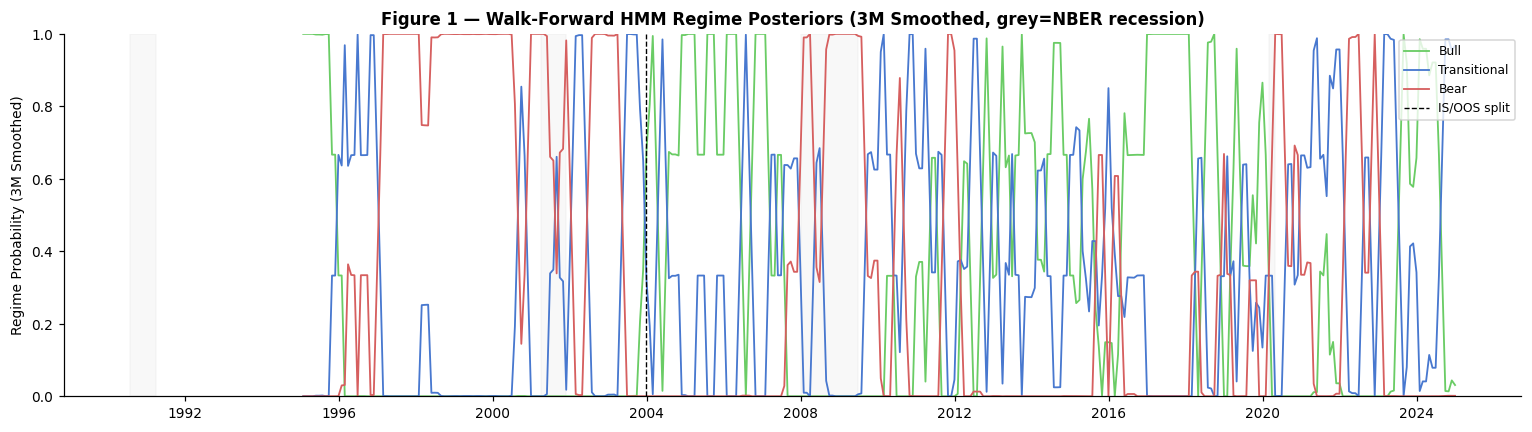

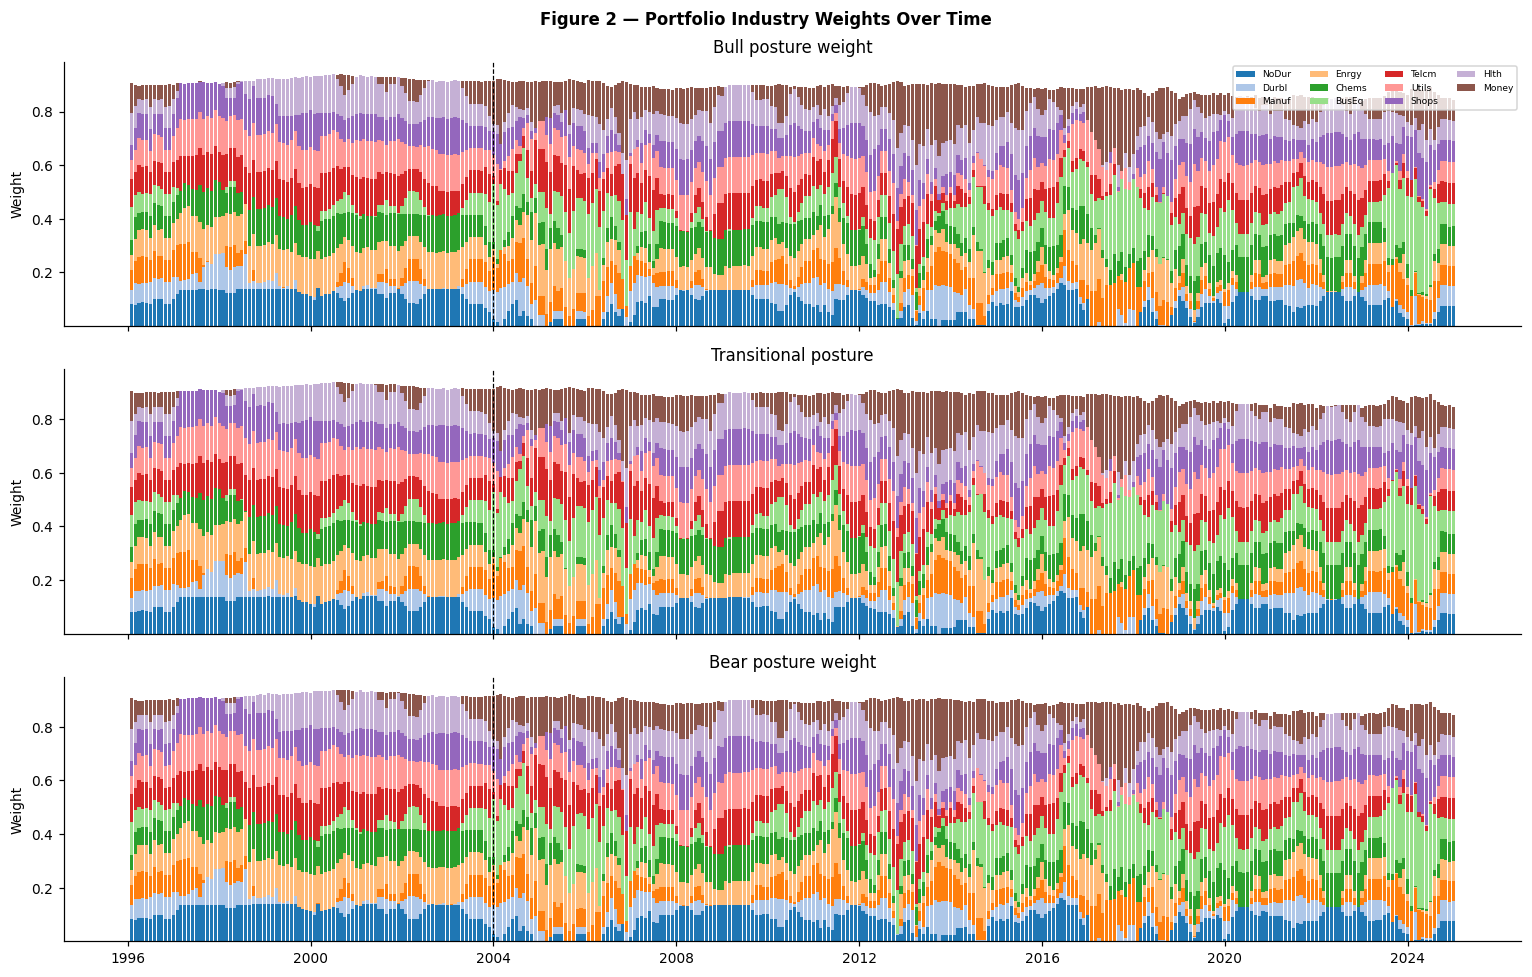

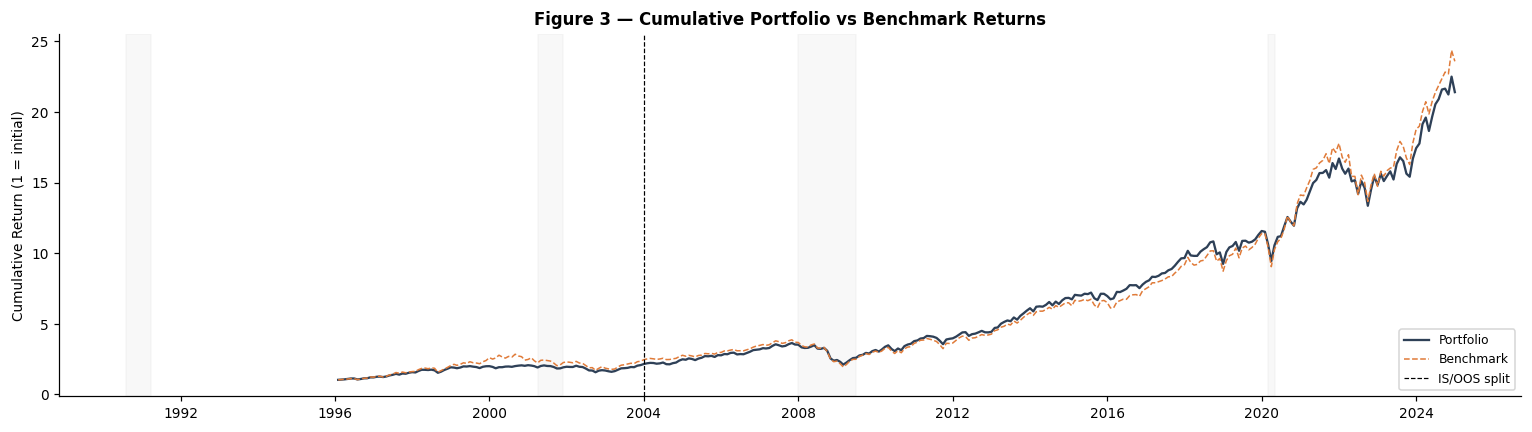

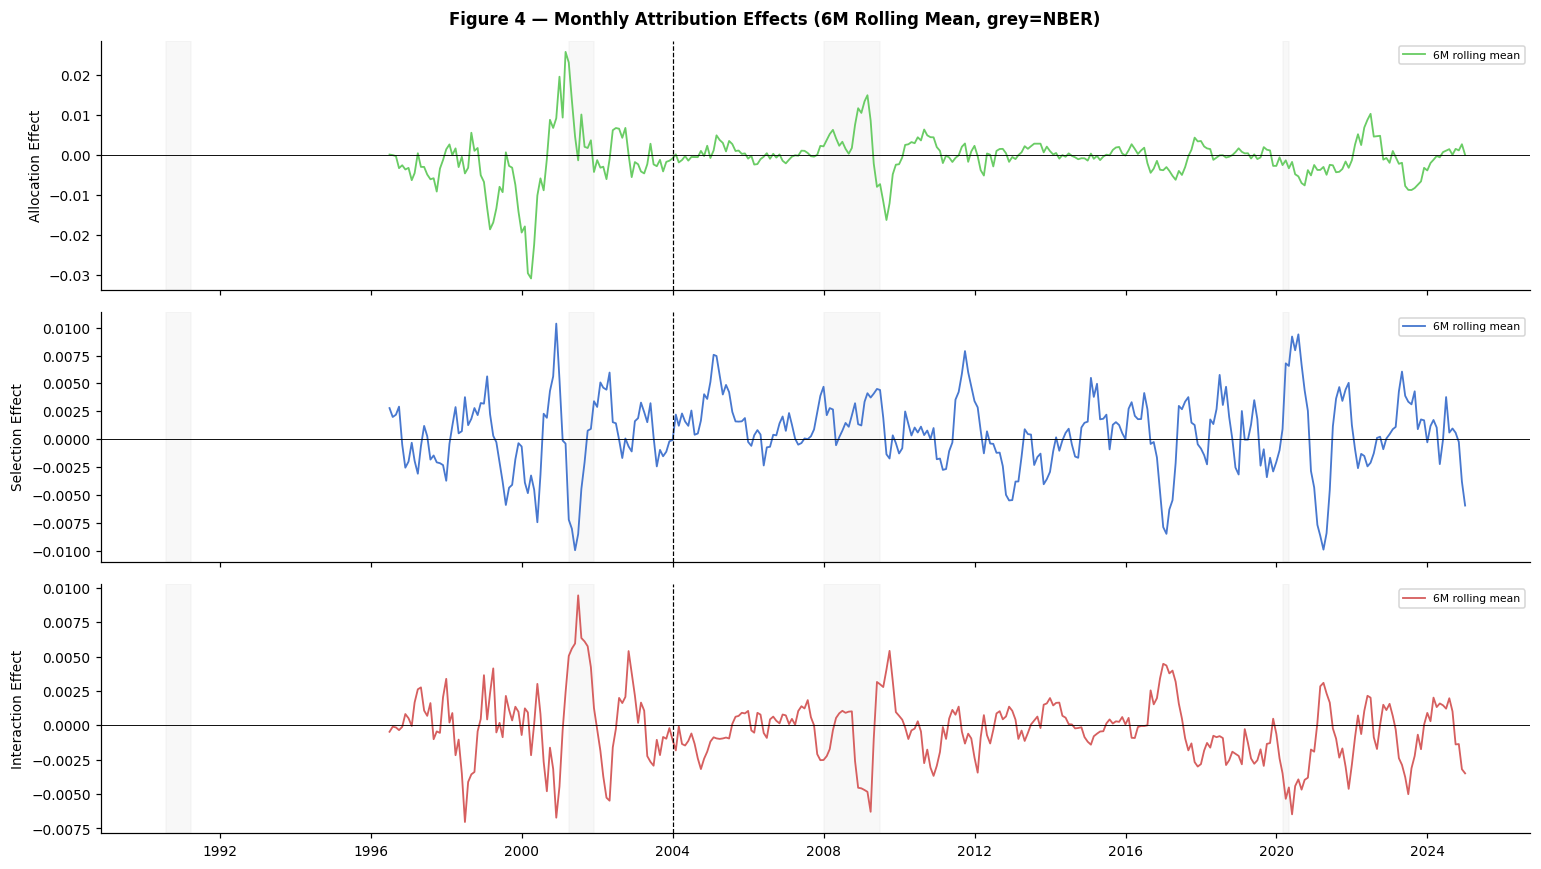

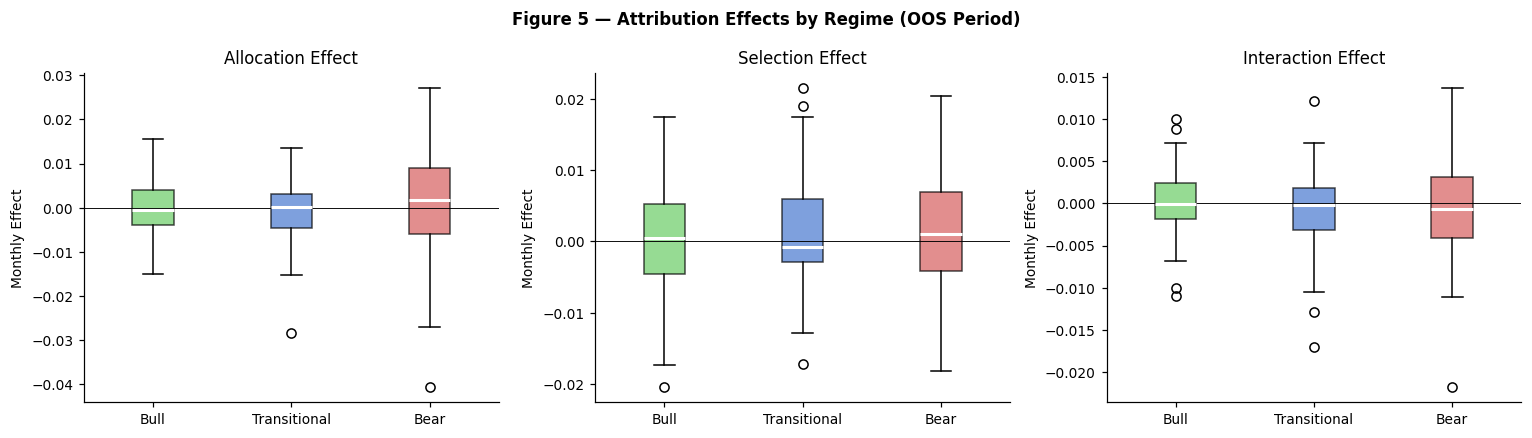

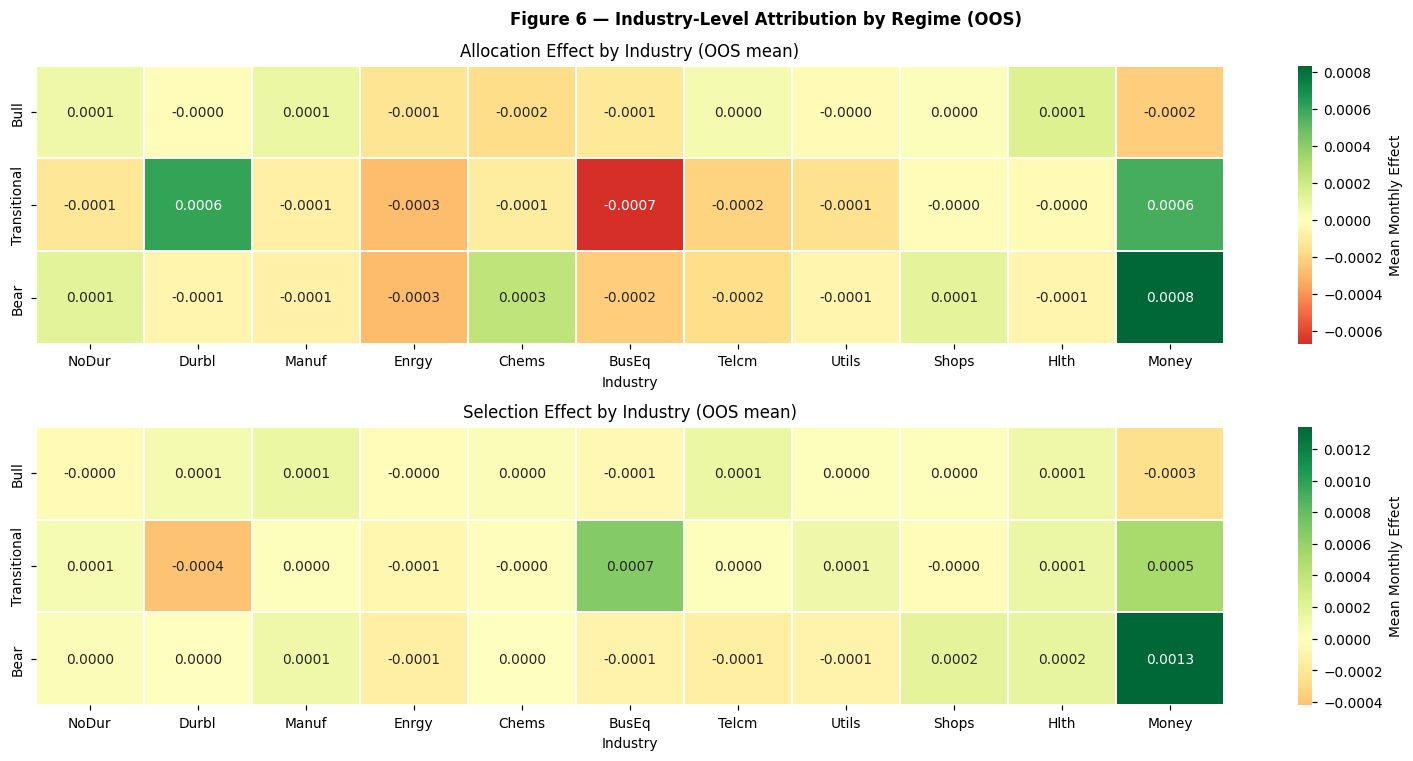


  TABLE 1 — CARINO-LINKED ATTRIBUTION (basis points)
  Period/Regime                            N      Alloc     Select      Inter     Active  Alloc-t    Sel-t
--------------------------------------------------------------------------------
  IS (1995-2003)                          96   -3567.85     -46.64     531.48   -3083.00    -0.90    -0.03
    IS (1995-2003) | Bull                  1      26.77     -44.14     -79.36     -96.72      nan      nan
    IS (1995-2003) | Transitional         28     815.78     433.91    -236.19    1013.50     0.80     0.77
    IS (1995-2003) | Bear                 67   -3459.92    -465.30     763.11   -3162.11    -1.20    -0.39
  OOS (2004-2024)                        252    -979.82   18046.56  -13442.58    3624.16    -0.40     1.50
    OOS (2004-2024) | Bull               113   -1198.88     593.94    -142.24    -747.18    -0.52     0.23
    OOS (2004-2024) | Transitional        87    -869.94    2178.37   -2081.30    -772.87    -0.65     1.30
    OOS (

In [17]:
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
})
IS_COLOR   = "#2E4057"
OOS_COLOR  = "#E07B39"
BULL_COLOR = "#6ACC65"
TRANS_COLOR= "#4878CF"
BEAR_COLOR = "#D65F5F"
NBER_COLOR = "0.88"

IS_END_TS    = pd.Timestamp(IS_END)
OOS_START_TS = pd.Timestamp(OOS_START)

def add_nber(ax, nber_df, alpha=0.22):
    in_rec, start = False, None
    for _, row in nber_df.iterrows():
        if row["recession"] == 1 and not in_rec:
            start, in_rec = row["date"], True
        elif row["recession"] == 0 and in_rec:
            ax.axvspan(start, row["date"], alpha=alpha, color=NBER_COLOR, zorder=0)
            in_rec = False
    if in_rec and start is not None:
        ax.axvspan(start, nber_df["date"].max(), alpha=alpha, color=NBER_COLOR, zorder=0)

SEP  = "=" * 80
SEP2 = "-" * 80

# ═══ PLOT 1 — Regime Probabilities ════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 4))
add_nber(ax, nber_raw)
ax.plot(regime_monthly["date"], regime_monthly["P_bull"],
        color=BULL_COLOR, lw=1.2, label="Bull")
ax.plot(regime_monthly["date"], regime_monthly["P_transitional"],
        color=TRANS_COLOR, lw=1.2, label="Transitional")
ax.plot(regime_monthly["date"], regime_monthly["P_bear"],
        color=BEAR_COLOR, lw=1.2, label="Bear")
ax.axvline(IS_END_TS, color="black", ls="--", lw=0.9, label="IS/OOS split")
ax.set_ylim(0, 1)
ax.set_ylabel("Regime Probability (3M Smoothed)")
ax.set_title(
    "Figure 1 — Walk-Forward HMM Regime Posteriors (3M Smoothed, grey=NBER recession)",
    fontweight="bold"
)
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

# ═══ PLOT 2 — Portfolio Weights Over Time ═════════════════════════
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
postures  = ["Bull posture weight", "Transitional posture", "Bear posture weight"]
colors    = sns.color_palette("tab20", n_colors=len(NAMED_INDUSTRIES))
for ax, title in zip(axes, postures):
    bottom = np.zeros(len(port_weights_df))
    for i, ind in enumerate(NAMED_INDUSTRIES):
        vals = port_weights_df[ind].values
        ax.bar(port_weights_df.index, vals, bottom=bottom,
               color=colors[i], label=ind, width=25)
        bottom += vals
    ax.axvline(IS_END_TS, color="black", ls="--", lw=0.8)
    ax.set_ylabel("Weight")
    ax.set_title(title)
axes[0].legend(fontsize=6, loc="upper right", ncol=4)
fig.suptitle("Figure 2 — Portfolio Industry Weights Over Time", fontweight="bold")
plt.tight_layout()
plt.show()

# ═══ PLOT 3 — Cumulative Returns ══════════════════════════════════
cum_port  = (1 + returns_df["portfolio_ret"]).cumprod()
cum_bench = (1 + returns_df["benchmark_ret"]).cumprod()
fig, ax = plt.subplots(figsize=(14, 4))
add_nber(ax, nber_raw)
ax.plot(cum_port.index,  cum_port.values,  color=IS_COLOR,  lw=1.5, label="Portfolio")
ax.plot(cum_bench.index, cum_bench.values, color=OOS_COLOR, lw=1.0, ls="--", label="Benchmark")
ax.axvline(IS_END_TS, color="black", ls="--", lw=0.8, label="IS/OOS split")
ax.set_ylabel("Cumulative Return (1 = initial)")
ax.set_title("Figure 3 — Cumulative Portfolio vs Benchmark Returns", fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ═══ PLOT 4 — Attribution Effects Over Time ═══════════════════════
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
for ax, col, label, color in [
    (axes[0], "alloc", "Allocation Effect", BULL_COLOR),
    (axes[1], "sel",   "Selection Effect",  TRANS_COLOR),
    (axes[2], "inter", "Interaction Effect", BEAR_COLOR),
]:
    add_nber(ax, nber_raw)
    ax.plot(attr_df.index, attr_df[col].rolling(6).mean(),
            color=color, lw=1.2, label=f"6M rolling mean")
    ax.axhline(0, color="black", lw=0.6)
    ax.axvline(IS_END_TS, color="black", ls="--", lw=0.8)
    ax.set_ylabel(label)
    ax.legend(fontsize=7, loc="upper right")
fig.suptitle("Figure 4 — Monthly Attribution Effects (6M Rolling Mean, grey=NBER)",
             fontweight="bold")
plt.tight_layout()
plt.show()

# ═══ PLOT 5 — Attribution by Regime (Box Plot) ════════════════════
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
regime_order = ["Bull","Transitional","Bear"]
colors_box   = [BULL_COLOR, TRANS_COLOR, BEAR_COLOR]
for ax, col, label in [
    (axes[0], "alloc", "Allocation Effect"),
    (axes[1], "sel",   "Selection Effect"),
    (axes[2], "inter", "Interaction Effect"),
]:
    data_by_regime = [
        attr_with_regime.loc[
            (attr_with_regime["regime"]==r) & (attr_with_regime.index >= OOS_START_TS),
            col
        ].dropna().values
        for r in regime_order
    ]
    bp = ax.boxplot(data_by_regime, labels=regime_order, patch_artist=True,
                   medianprops={"color":"white", "lw":2})
    for patch, color in zip(bp["boxes"], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.axhline(0, color="black", lw=0.6)
    ax.set_title(label)
    ax.set_ylabel("Monthly Effect")
fig.suptitle("Figure 5 — Attribution Effects by Regime (OOS Period)", fontweight="bold")
plt.tight_layout()
plt.show()

# ═══ PLOT 6 — Industry Attribution Heatmap (OOS) ══════════════════
oos_attr = attr_with_regime[attr_with_regime.index >= OOS_START_TS]
alloc_cols = [f"alloc_{ind}" for ind in NAMED_INDUSTRIES]
sel_cols   = [f"sel_{ind}"   for ind in NAMED_INDUSTRIES]

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for ax, cols, label in [
    (axes[0], alloc_cols, "Allocation Effect by Industry (OOS mean)"),
    (axes[1], sel_cols,   "Selection Effect by Industry (OOS mean)"),
]:
    mean_by_regime = pd.DataFrame({
        regime: oos_attr[oos_attr["regime"]==regime][cols].mean()
        for regime in ["Bull","Transitional","Bear"]
    })
    mean_by_regime.index = NAMED_INDUSTRIES
    sns.heatmap(mean_by_regime.T, ax=ax, cmap="RdYlGn", center=0,
               annot=True, fmt=".4f", linewidths=0.3,
               cbar_kws={"label":"Mean Monthly Effect"})
    ax.set_title(label)
    ax.set_xlabel("Industry")
fig.suptitle("Figure 6 — Industry-Level Attribution by Regime (OOS)", fontweight="bold")
plt.tight_layout()
plt.show()

# ═══ TABLE 1 — Carino-Linked Attribution by Period and Regime ═════
print()
print(SEP)
print("  TABLE 1 — CARINO-LINKED ATTRIBUTION (basis points)")
print(SEP)
print(f"  {'Period/Regime':<35} {'N':>6} {'Alloc':>10} {'Select':>10} {'Inter':>10} {'Active':>10} {'Alloc-t':>8} {'Sel-t':>8}")
print(SEP2)
for _, row in carino_results.iterrows():
    if pd.isna(row["alloc_linked"]):
        continue
    print(f"  {row['regime']:<35} {row['n_months']:>6.0f} "
          f"{row['alloc_linked']*10000:>10.2f} {row['sel_linked']*10000:>10.2f} "
          f"{row['inter_linked']*10000:>10.2f} {row['active_linked']*10000:>10.2f} "
          f"{row.get('alloc_t', float('nan')):>8.2f} {row.get('sel_t', float('nan')):>8.2f}")
print(SEP)
print("  Values in basis points (×10,000). t-statistics based on monthly time-series.")

# ═══ TABLE 2 — Ferson-Schadt Regression Results ════════════════════
print()
print(SEP)
print("  TABLE 2 — FERSON-SCHADT CONDITIONAL PERFORMANCE TESTS")
print("  dep = alpha + beta_bull*P_bull + beta_trans*P_trans + gamma*STREV + eps")
print("  Newey-West SEs (6-month lag). Base regime = Bear (intercept).")
print(SEP)
print(f"  {'Dep Variable':<30} {'N':>5} {'alpha':>8} {'b_bull':>8} {'b_trans':>8} {'gamma':>8} "
      f"{'R2':>6} {'F(bull=trans)':>14} {'F_p':>8}")
print(SEP2)
for _, row in fs_df.iterrows():
    def fmt_t(coef, t, p):
        stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
        return f"{coef:7.4f}{stars}"
    print(f"  {row['dep_var']:<30} {row['n_obs']:>5.0f} "
          f"{fmt_t(row['alpha'], row['alpha_t'], row['alpha_p']):>11} "
          f"{fmt_t(row['beta_bull'], row['beta_bull_t'], row['beta_bull_p']):>11} "
          f"{fmt_t(row['beta_trans'], row['beta_trans_t'], row['beta_trans_p']):>11} "
          f"{fmt_t(row['gamma_strev'], row['gamma_t'], row['gamma_p']):>11} "
          f"{row['R2']:>6.3f} {row['F_bull_eq_trans']:>14.2f} {row['F_pval']:>8.4f}")
print(SEP)
print("  *p<0.10  **p<0.05  ***p<0.01  (Newey-West, 6-month lag)")

# ═══ TABLE 3 — Performance Metrics ════════════════════════════════
print()
print(SEP)
print("  TABLE 3 — PERFORMANCE SUMMARY (annualised)")
print(SEP)
print(f"  {'Period/Regime':<35} {'N':>5} {'Port Ret':>9} {'Bench Ret':>9} "
      f"{'Active Ret':>10} {'Port Vol':>9} {'Sharpe':>7} {'IR':>7} {'Hit%':>7}")
print(SEP2)
for _, row in perf_df.iterrows():
    if row.isnull().all():
        continue
    print(f"  {row['label']:<35} {row['n_months']:>5.0f} "
          f"{row['port_ret_ann']*100:>9.2f}% {row['bench_ret_ann']*100:>9.2f}% "
          f"{row['active_ret_ann']*100:>10.2f}% {row['port_vol_ann']*100:>9.2f}% "
          f"{row['sharpe_port']:>7.2f} {row['info_ratio']:>7.2f} "
          f"{row['pct_positive']*100:>7.1f}%")
print(SEP)

# ═══ TABLE 4 — H₁ and H₂ Hypothesis Summary ═══════════════════════
print()
print(SEP)
print("  TABLE 4 — HYPOTHESIS TEST SUMMARY")
print(SEP)

# H1: allocation effect positive/significant in bull, not in bear
oos_alloc_full = fs_df[fs_df["dep_var"] == "Allocation (OOS)"]
oos_sel_full   = fs_df[fs_df["dep_var"] == "Selection (OOS)"]

if not oos_alloc_full.empty:
    row = oos_alloc_full.iloc[0]
    h1_bull_pos  = row["beta_bull"] > 0
    h1_bull_sig  = row["beta_bull_p"] < 0.10
    h1_bear_neg  = row["alpha"] <= 0  # intercept = bear baseline
    h1_f_sig     = row["F_pval"] < 0.10
    h1_verdict   = "SUPPORTED" if h1_bull_pos and h1_bull_sig else "NOT SUPPORTED"
    print(f"  H₁ (Allocation regime-dependence):")
    print(f"    Beta_bull = {row['beta_bull']:.4f} (t={row['beta_bull_t']:.2f}, p={row['beta_bull_p']:.3f})")
    print(f"    Bear baseline (alpha) = {row['alpha']:.4f} (t={row['alpha_t']:.2f}, p={row['alpha_p']:.3f})")
    print(f"    F-test (bull=trans): F={row['F_bull_eq_trans']:.2f}, p={row['F_pval']:.3f}")
    print(f"    Verdict: {h1_verdict}")

if not oos_sel_full.empty:
    row = oos_sel_full.iloc[0]
    # H2: selection significant in at least one regime
    h2_any_sig = any([
        row["beta_bull_p"] < 0.10,
        row["beta_trans_p"] < 0.10,
        row["alpha_p"] < 0.10,
    ])
    # H2: variance of selection < variance of allocation
    oos_mask_attr = attr_with_regime.index >= OOS_START_TS
    sel_regime_means  = attr_with_regime[oos_mask_attr].groupby("regime")["sel"].mean()
    alloc_regime_means= attr_with_regime[oos_mask_attr].groupby("regime")["alloc"].mean()
    h2_var_smaller    = sel_regime_means.var() < alloc_regime_means.var()
    h2_verdict = "SUPPORTED" if h2_any_sig and h2_var_smaller else \
                 "PARTIALLY SUPPORTED" if h2_any_sig or h2_var_smaller else "NOT SUPPORTED"
    print(f"\n  H₂ (Selection stability):")
    print(f"    Beta_bull = {row['beta_bull']:.4f} (p={row['beta_bull_p']:.3f}) "
          f"| Beta_trans = {row['beta_trans']:.4f} (p={row['beta_trans_p']:.3f}) "
          f"| Bear alpha = {row['alpha']:.4f} (p={row['alpha_p']:.3f})")
    print(f"    Variance of selection regime means : {sel_regime_means.var():.8f}")
    print(f"    Variance of allocation regime means: {alloc_regime_means.var():.8f}")
    print(f"    Verdict: {h2_verdict}")

print(SEP)
print("\nNotebook 3 complete. All tables and figures produced above.")
print("Save outputs: regime_posteriors_monthly.parquet already cached.")
